<a href="https://colab.research.google.com/github/HarikaBarla5/emotion-project/blob/main/AI_interview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Facial Emotion Recognition Data Requirements

For facial emotion recognition, the primary data type required is **annotated image and/or video datasets**. These datasets need to include a diverse range of human faces exhibiting various emotions.

*   **Image Datasets**: Each image should be labeled with a specific emotion category.
    *   **Desired Resolution**: Images should preferably have a minimum resolution of `640x480` pixels to capture sufficient facial detail. Higher resolutions are better, but a balance with dataset size and processing power is necessary.
    *   **Emotion Categories**: Standard emotion categories typically include `happy`, `sad`, `angry`, `fearful`, `disgusted`, `surprised`, and `neutral`. Additional categories like `contempt` or `excitement` may be considered for more nuanced analysis.

*   **Video Datasets**: Videos are crucial for capturing temporal dynamics of emotion expression. Each frame or segment of the video should be labeled with emotion categories.
    *   **Desired Frame Rate**: A minimum of `24-30 frames per second (fps)` is recommended to capture subtle emotional shifts.
    *   **Duration**: Video clips should vary in duration, typically from `3-10 seconds`, to show the onset, apex, and offset of emotional expressions.
    *   **Annotation**: Frame-level or event-based annotation for emotions, potentially including intensity levels.

### Open-Source Datasets for Data Acquisition

To acquire data for both facial emotion recognition and spoken answer evaluation, we can leverage existing open-source datasets. This approach saves time and resources compared to creating custom datasets from scratch.

#### Facial Emotion Recognition Datasets:

*   **FER2013**: A widely used dataset consisting of `48x48` pixel grayscale images of faces, labeled with 7 emotion categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral). It contains ~35,000 images.
*   **AffectNet**: A large dataset with over 1 million facial images from the internet, manually annotated for the presence of 11 discrete emotion categories and the intensity of valence and arousal. It's more diverse and larger than FER2013.
*   **CK+ (Extended Cohn-Kanade Dataset)**: A dataset of posed and spontaneous facial expressions. It includes sequences of images from neutral to peak expression, along with FACS (Facial Action Coding System) action unit codes and emotion labels for peak frames. It contains ~600 sequences from 123 subjects.
*   **RAF-DB (Real-world Affective Faces Database)**: A diverse dataset containing approximately 30,000 facial images with accurate annotations of 7 basic and 11 compound emotion categories. The images are collected from real-world conditions.
*   **JAFFE (Japanese Female Facial Expression) Database**: Contains 213 images of 7 facial expressions (6 basic facial expressions + 1 neutral) posed by 10 Japanese female models. Each image is rated on 6 emotion adjectives by 60 Japanese subjects.

#### Spoken Answer Evaluation Datasets:

*   **VCTK (Voice Cloning Toolkit) Corpus**: Contains speech data uttered by 109 native speakers of English with various accents. Each speaker reads around 400 sentences. While primarily for speech synthesis, it can be used for training robust ASR models which are crucial for transcription accuracy in spoken answer evaluation.
*   **LibriSpeech**: A corpus of approximately 1000 hours of 16kHz read English speech, prepared by Google for automatic speech recognition (ASR) research. It's suitable for training and evaluating ASR systems that would transcribe spoken answers.
*   **Common Voice (Mozilla)**: A large, open-source, multi-language dataset of voices. Volunteers record sentences from a public domain text, and other volunteers validate the recordings. This can be used to build custom ASR models or enhance existing ones for specific accents or linguistic nuances.
*   **AMI Meeting Corpus**: Contains recordings of naturally occurring meetings. This dataset includes audio, video, and rich annotations (transcripts, speaker turns, named entities, etc.), which could be valuable for understanding conversational dynamics in spoken answers, though it's not directly for 'answer evaluation'.
*   **Custom Datasets for Question-Answering**: While no large public dataset directly provides 'spoken answers evaluated against questions', components can be found:
    *   **SQuAD (Stanford Question Answering Dataset)**: A reading comprehension dataset, consisting of questions posed by crowdworkers on a set of Wikipedia articles, where the answer to every question is a segment of text, or span, from the corresponding reading passage. This is text-based but provides a structure for question-answer pairs.
    *   **NarrativeQA**: Requires models to answer questions by reading passages and/or summaries of books and movies. Again, text-based, but valuable for question-answering logic.

For spoken answer evaluation, it's highly probable that a custom dataset will need to be created, combining audio recordings of responses to specific interview questions with expert-rated quality scores and accurate transcripts, as fully pre-packaged datasets for this exact purpose are less common.

In [3]:
!pip install speechrecognition
!pip install sentence-transformers
!pip install sounddevice
!pip install transformers
!pip install torch

In [2]:
!pip install speechrecognition
import speech_recognition as sr
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 65.6 MB/s eta 0:00:00


In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
questions = [
    {
        "question": "Explain what is Machine Learning?",
        "ideal_answer": "Machine learning is a subset of artificial intelligence that enables systems to learn from data and improve without being explicitly programmed."
    },
    {
        "question": "What is overfitting?",
        "ideal_answer": "Overfitting occurs when a model learns noise in the training data and performs poorly on unseen data."
    },
    {
        "question": "Explain CNN.",
        "ideal_answer": "A Convolutional Neural Network is a deep learning model mainly used for image processing and computer vision tasks."
    }
]

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    '/content/drive/MyDrive/fer2013.csv',
    encoding='latin1',
    engine='python',
    compression='zip',
    on_bad_lines='warn' # This should skip malformed lines for the python engine
)

In [24]:
df=pd.DataFrame(df)
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [25]:
emotions = { #list of available emotions in the dataset
    0:"Angry",
    1:"Disgust",
    2:"Fear",
    3:"Happy",
    4:"Sad",
    5:"Surprize",
    6:"Neutral"
}

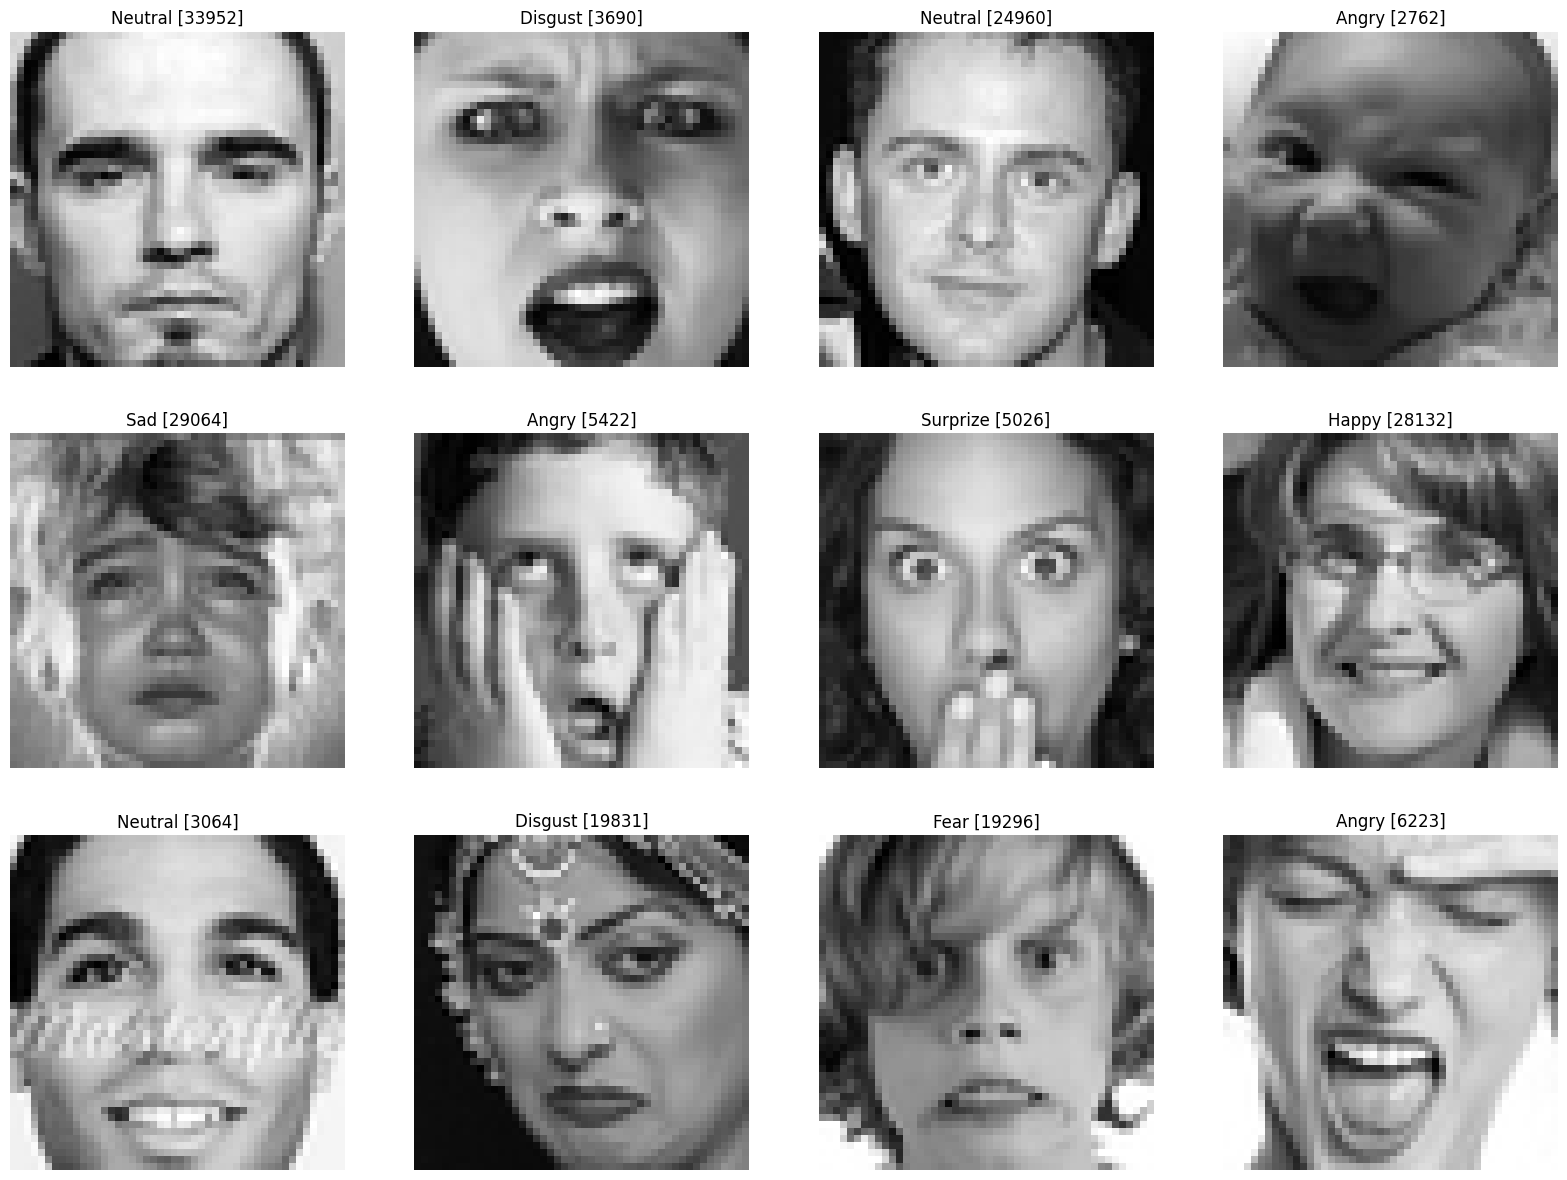

In [26]:
import matplotlib.pyplot as plt

def visualize_images(n_img=4):
    indices = np.random.randint(0,df.shape[0],size=n_img)
#     print(indices)
    plt.figure(figsize=(20,20))
    for i,l in zip(indices,range(0,len(indices))):
        image_ar = np.array([i for i in  df['pixels'][i].split()] , dtype='float')
        pixels = np.reshape(image_ar,(48,48))
        ax = plt.subplot(4,4,l+1)
        plt.imshow(pixels,cmap='gray')
        plt.title(emotions[df['emotion'][i]]+" ["+str(i)+"]")
        plt.xticks()
        plt.yticks([])
        plt.axis("off")
visualize_images(12)

In [27]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [28]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Input,Dropout,GlobalAveragePooling2D,Flatten,Conv2D,BatchNormalization,Activation,MaxPooling2D
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,SGD,RMSprop

In [29]:
X_train,y_train = [],[]
X_val,y_val = [],[]
X_test,y_test = [],[]
for index,row in df.iterrows():
    k = row['pixels'].split(" ")
    if row['Usage'] == 'Training':
        X_train.append(np.array(k))
        y_train.append(row['emotion'])
    elif row['Usage'] == 'PrivateTest':
        X_test.append(np.array(k))
        y_test.append(row['emotion'])
    elif row['Usage'] == 'PublicTest':
        X_val.append(np.array(k))
        y_val.append(row['emotion'])

X_train = np.array(X_train,dtype='float')
y_train = np.array(y_train)
X_test = np.array(X_test,dtype='float')
y_test = np.array(y_test)
X_val = np.array(X_val,dtype='float')
y_val = np.array(y_val)

In [30]:

X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape

((28709, 2304), (28709,), (3589, 2304), (3589,), (3589, 2304), (3589,))

In [31]:
from tensorflow.keras.utils import to_categorical

X_train = X_train.reshape(X_train.shape[0],48,48,1)
X_test = X_test.reshape(X_test.shape[0],48,48,1)
X_val = X_val.reshape(X_val.shape[0],48,48,1)

y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)
y_val = to_categorical(y_val,num_classes=7)

X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape

((28709, 48, 48, 1),
 (28709, 7),
 (3589, 48, 48, 1),
 (3589, 7),
 (3589, 48, 48, 1),
 (3589, 7))

PREPROCESSING IMAGES

In [32]:
no_of_classes=7

model=Sequential()

#1st CNN layer
model.add(Conv2D(64,(3,3),padding="same",input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


#2nd CNN layer
model.add(Conv2D(128,(5,5),padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

#3rd CNN layer
model.add(Conv2D(512,(3,3),padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

#4th CNN layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

#Fully connected 1st layer
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
# Fully connected layer 2nd layer
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(no_of_classes,activation="softmax"))
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpointer = [EarlyStopping(monitor = 'val_accuracy', verbose = 1,
                              restore_best_weights=True,mode="max",patience = 10),
                              ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                              save_best_only=True,mode="max")]

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=30,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)

Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2726 - loss: 1.9171
Epoch 1: val_accuracy improved from -inf to 0.31123, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.2727 - loss: 1.9169 - val_accuracy: 0.3112 - val_loss: 1.7106
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4541 - loss: 1.4171
Epoch 2: val_accuracy improved from 0.31123 to 0.47005, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4541 - loss: 1.4171 - val_accuracy: 0.4700 - val_loss: 1.4181
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5198 - loss: 1.2608
Epoch 3: val_accuracy improved from 0.47005 to 0.54639, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5198 - loss: 1.2608 - val_accuracy: 0.5464 - val_loss: 1.1946
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5513 - loss: 1.1795
Epoch 4: val_accuracy did not improve from 0.54639
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5513 - loss: 1.1795 - val_accuracy: 0.5316 - val_loss: 1.2004
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5746 - loss: 1.1188
Epoch 5: val_accuracy did not improve from 0.54639
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.5746 - loss: 1.1188 - val_accuracy: 0.5341 - val_loss: 1.2193
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5937 - loss: 1.0683
Epoch 6: val_accuracy improved from 0.54639 to 0.55670, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5937 - loss: 1.0683 - val_accuracy: 0.5567 - val_loss: 1.1641
Epoch 7/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6124 - loss: 1.0295
Epoch 7: val_accuracy improved from 0.55670 to 0.58596, saving model to best_model.h5


...

898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.6425 - loss: 0.9581 - val_accuracy: 0.5915 - val_loss: 1.0865
Epoch 9/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6595 - loss: 0.9109
Epoch 9: val_accuracy did not improve from 0.59153
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6595 - loss: 0.9109 - val_accuracy: 0.5589 - val_loss: 1.1964
Epoch 10/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6820 - loss: 0.8617
Epoch 10: val_accuracy improved from 0.59153 to 0.60992, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.6820 - loss: 0.8617 - val_accuracy: 0.6099 - val_loss: 1.0440
Epoch 11/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7024 - loss: 0.8013
Epoch 11: val_accuracy did not improve from 0.60992
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.7024 - loss: 0.8013 - val_accuracy: 0.6077 - val_loss: 1.0509
Epoch 12/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7176 - loss: 0.7609
Epoch 12: val_accuracy improved from 0.60992 to 0.61911, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.7176 - loss: 0.7609 - val_accuracy: 0.6191 - val_loss: 1.0649
Epoch 13/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7412 - loss: 0.6934
Epoch 13: val_accuracy did not improve from 0.61911
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7411 - loss: 0.6935 - val_accuracy: 0.6130 - val_loss: 1.0936
Epoch 14/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7636 - loss: 0.6416
Epoch 14: val_accuracy improved from 0.61911 to 0.62775, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.7636 - loss: 0.6417 - val_accuracy: 0.6278 - val_loss: 1.1025
Epoch 15/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7793 - loss: 0.6051
Epoch 15: val_accuracy did not improve from 0.62775
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.7793 - loss: 0.6052 - val_accuracy: 0.6266 - val_loss: 1.1708
Epoch 16/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7924 - loss: 0.5580
Epoch 16: val_accuracy did not improve from 0.62775
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7924 - loss: 0.5581 - val_accuracy: 0.6278 - val_loss: 1.1395
Epoch 17/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8154 - loss: 0.5124
Epoch 17: val_accuracy improved from 0.62775 to 0.63527, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8154 - loss: 0.5124 - val_accuracy: 0.6353 - val_loss: 1.1589
Epoch 18/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8301 - loss: 0.4644
Epoch 18: val_accuracy did not improve from 0.63527
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8301 - loss: 0.4645 - val_accuracy: 0.6155 - val_loss: 1.2467
Epoch 19/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8333 - loss: 0.4540
Epoch 19: val_accuracy did not improve from 0.63527
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8333 - loss: 0.4540 - val_accuracy: 0.6219 - val_loss: 1.2784
Epoch 20/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8449 - loss: 0.4236
Epoch 20: val_accuracy did not improve from 0.63527
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8449 - loss: 0.4236 - val_accuracy: 0.6088 - val_loss: 1.3951
Epoch 21/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8577 - loss: 0.3902
Epoch 21: val_ac

FITTING THE MODEL WITH THE TRAINING AND VALIDATION DATA

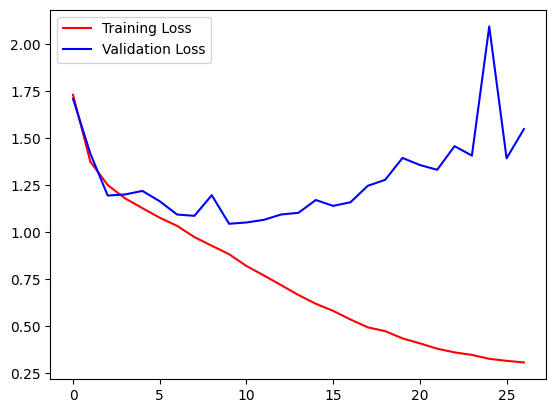

In [34]:
def loss_plot(history):
  plt.plot(history.history["loss"],'r', label="Training Loss")
  plt.plot(history.history["val_loss"],'b', label="Validation Loss")
  plt.legend()

loss_plot(history)

In [35]:
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


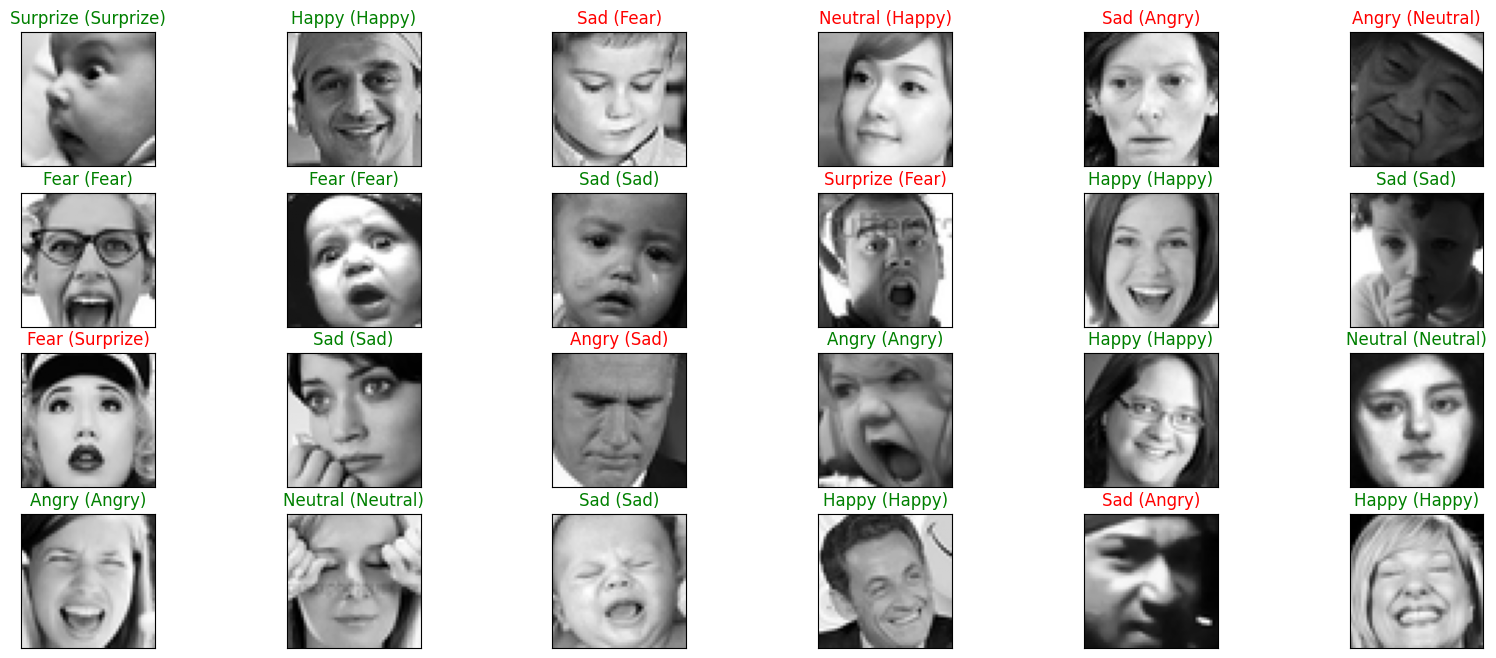

In [36]:
def check_images(X_test,y_pred,label_dict={}):

  figure = plt.figure(figsize=(20, 8))
  for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
      ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
      ax.imshow(np.squeeze(X_test[index]),cmap="gray")
      predict_index = label_dict[(y_pred[index])]
      true_index = label_dict[np.argmax(y_test,axis=1)[index]]

      ax.set_title("{} ({})".format((predict_index),
                                    (true_index)),
                                    color=("green" if predict_index == true_index else "red"))
check_images(X_test,y_pred,emotions)

In [37]:
from tensorflow.keras.metrics import  CategoricalAccuracy

In [39]:
X_test.shape

(3589, 48, 48, 1)

In [41]:
y_hat=model.predict(X_test)
acc = CategoricalAccuracy()
acc.update_state(y_test,y_hat)
acc.result().numpy()

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


np.float32(0.63917524)

In [43]:
model.evaluate(X_test,y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6418 - loss: 1.0671


[1.088686466217041, 0.6391752362251282]

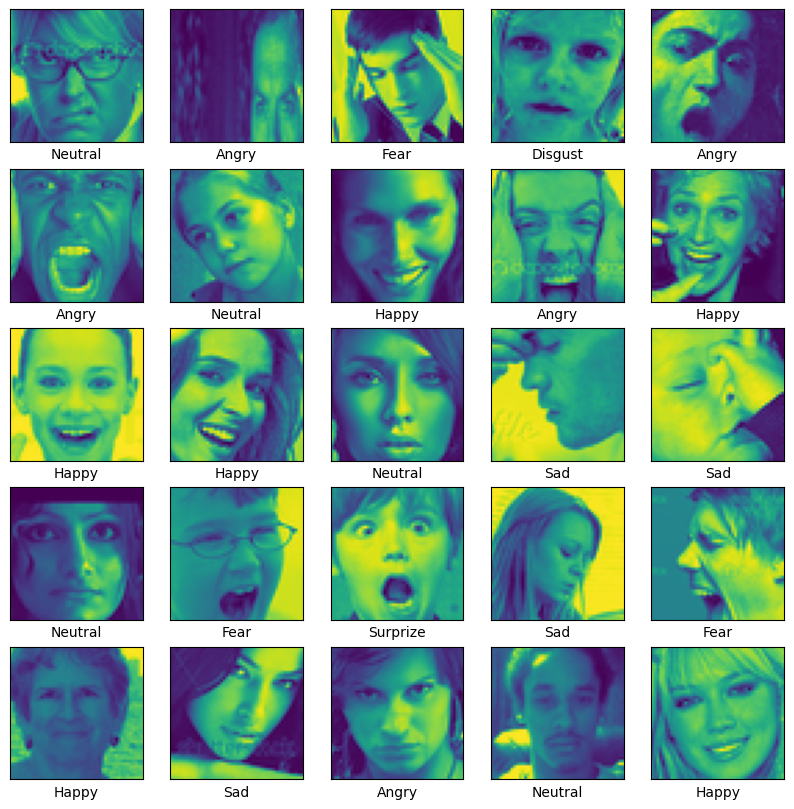

In [46]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i])
    plt.xlabel(emotions[y_pred[i]])
plt.show()

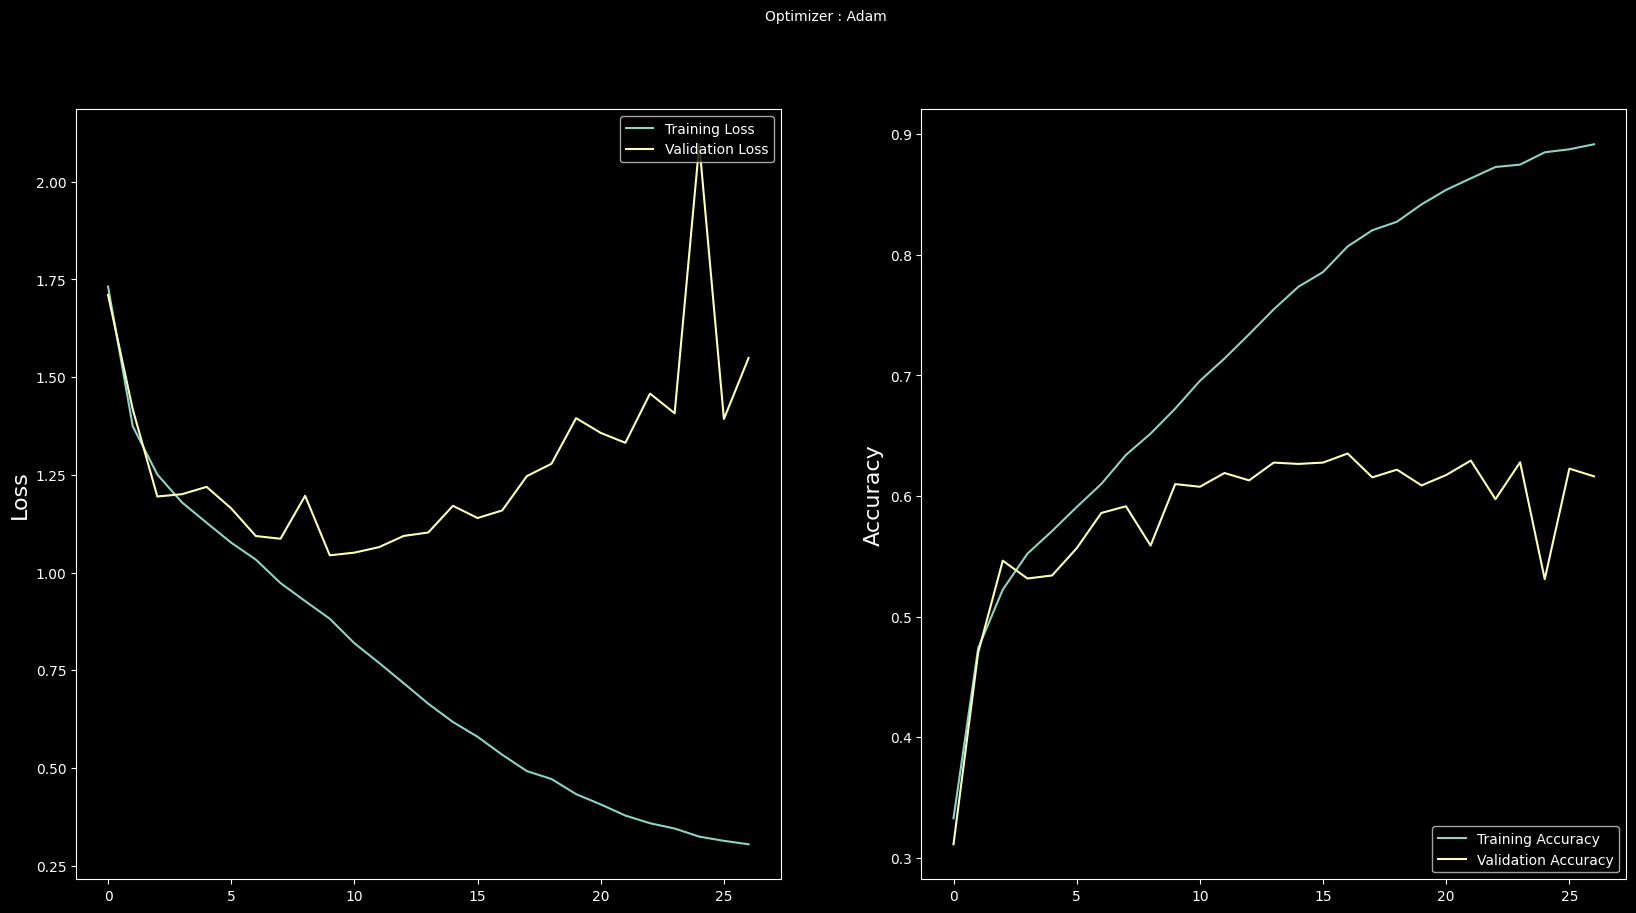

In [47]:
plt.style.use('dark_background')

plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : Adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

### Saving Your Trained Model

After training, you can save your Keras model, including its architecture, weights, and optimizer state, to a file. This allows you to load it later without needing to retrain it.

Since you are already using `ModelCheckpoint` to save the best model during training, you have `best_model.h5` saved. If you want to save the final model after all epochs (which might not be the 'best' if early stopping triggered), you can use `model.save()`.

In [48]:
import tensorflow as tf

# The ModelCheckpoint callback already saved the best model to 'best_model.h5'
# You can load it directly. If you wanted to save the final model after training:
# model.save('final_emotion_model.h5')

print("Model saved by ModelCheckpoint during training as 'best_model.h5'.")

Model saved by ModelCheckpoint during training as 'best_model.h5'.


### Loading Your Saved Model

To access and use your trained model in a new session or script, you just need to load it from the saved file. You do not need to redefine the model architecture or retrain it.

In [49]:
import tensorflow as tf

# Load the best model saved during training
loaded_model = tf.keras.models.load_model('best_model.h5')

# Now you can use 'loaded_model' for predictions or further evaluation
print("Model loaded successfully!")
loaded_model.summary()

# Example: Evaluate the loaded model on the test data
loss, accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Loaded model test accuracy: {accuracy:.4f}")

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,478,729 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

 Optimizer params: 2 (12.00 B)

Loaded model test accuracy: 0.6392


By following these steps, you only need to run the model definition and training code once. For subsequent uses, you can simply load the saved model and use it for inference.